Processed: 7_IR | Points: 243938
Processed: 7_OR1 | Points: 124602
Processed: 7_OR2 | Points: 243538
Processed: 7_OR3 | Points: 129969
Processed: 7_BA | Points: 244739
Processed: 14_BA | Points: 249146
Processed: 21_BA | Points: 243938
Processed: 14_IR | Points: 63788
Processed: 21_IR | Points: 244339
Processed: 14_OR1 | Points: 245140
Processed: 21_OR1 | Points: 128663
Processed: 21_OR2 | Points: 246342
Processed: 21_OR3 | Points: 130549
Processed: N | Points: 243938

✅ Saved to CWRU_48khz_raw.parquet (High Speed)


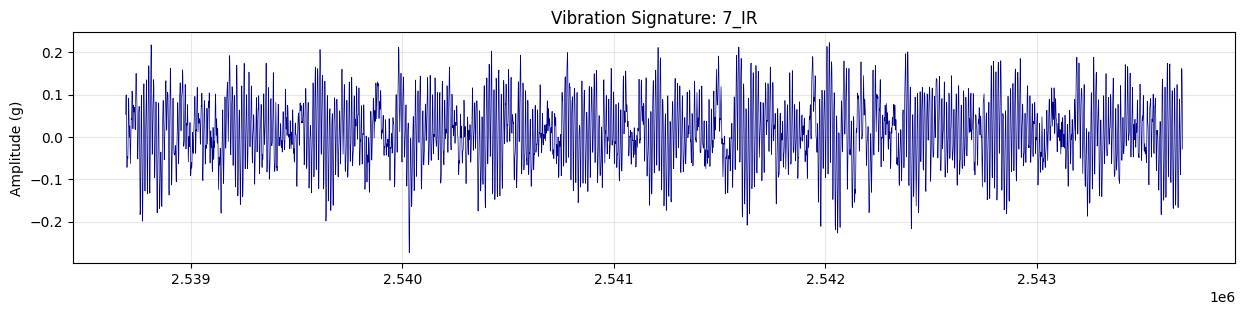

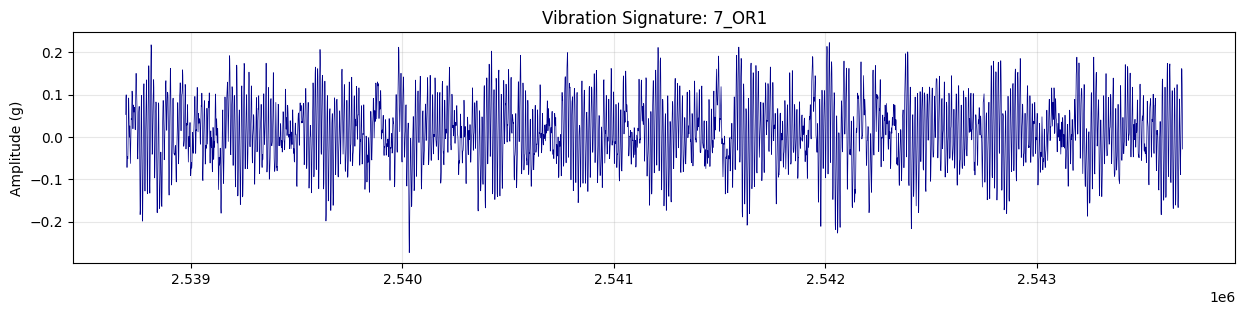

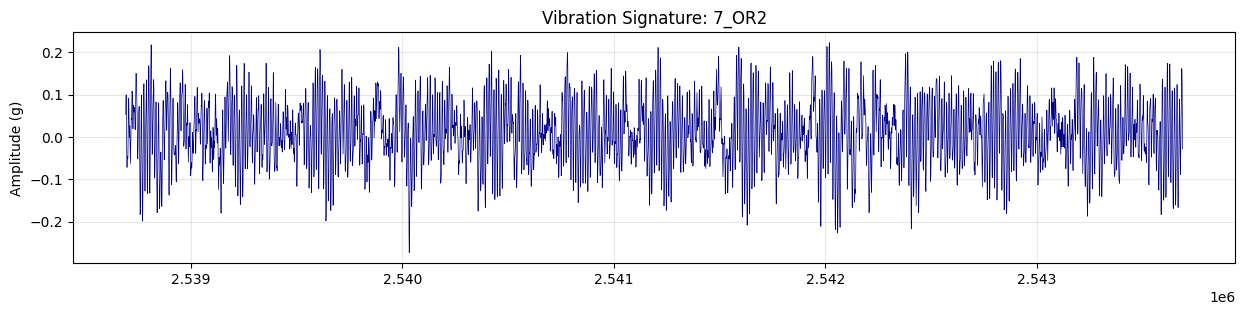

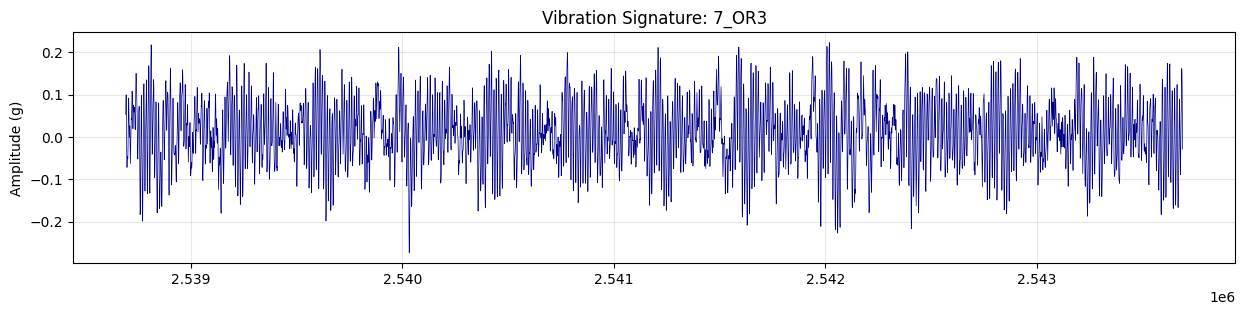

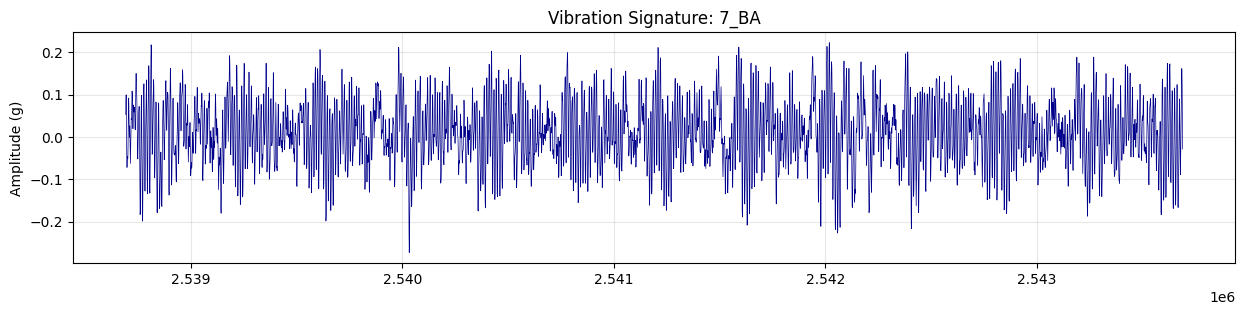

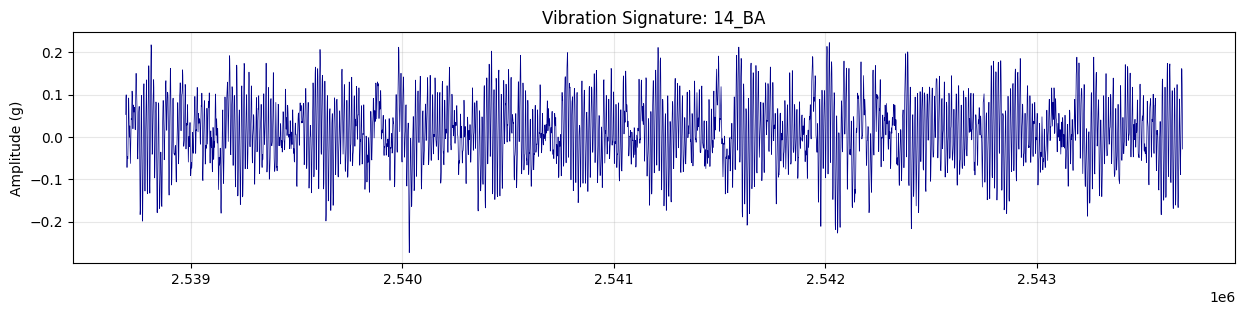

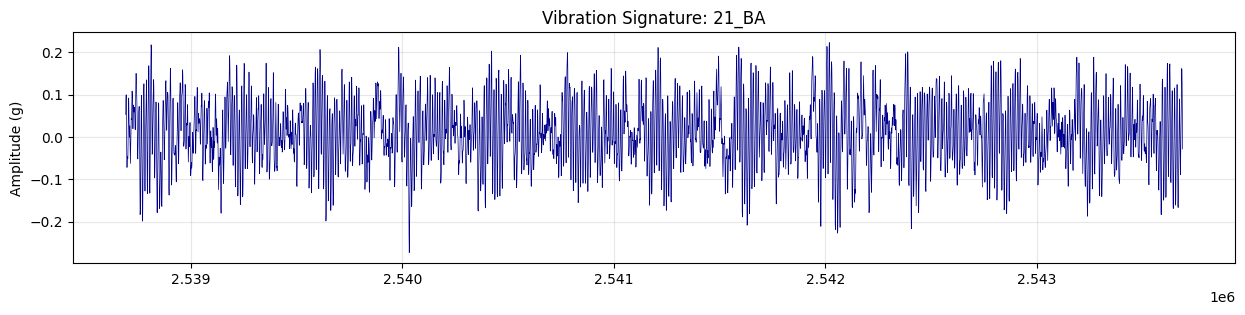

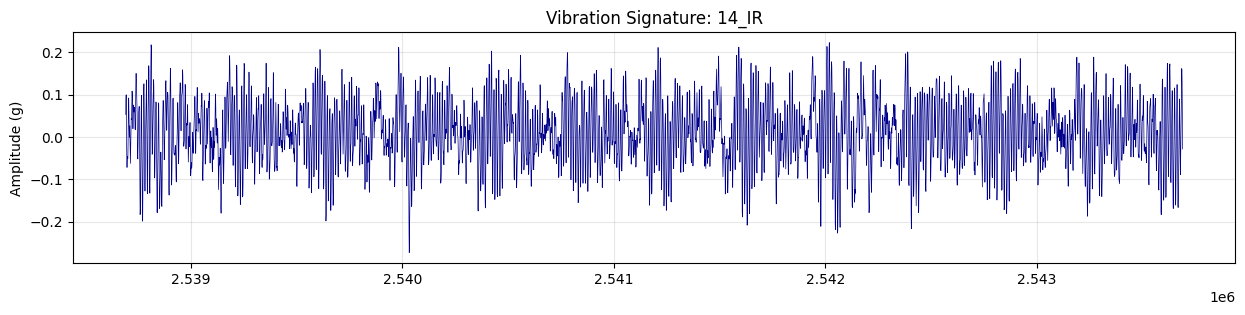

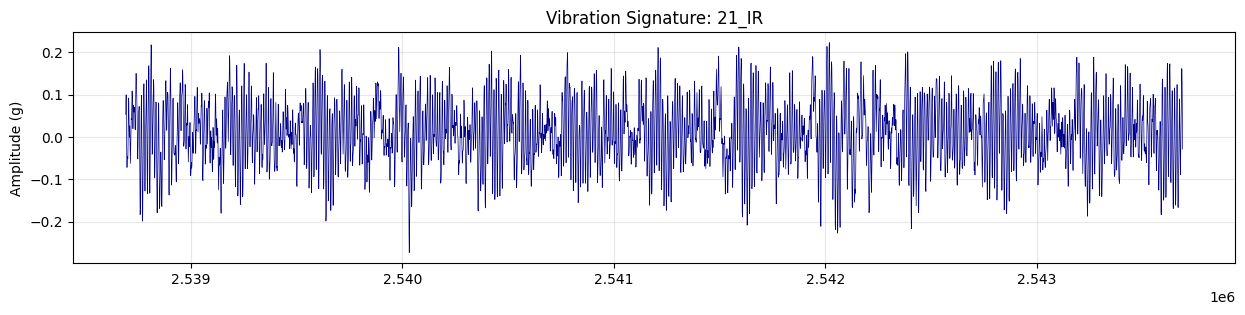

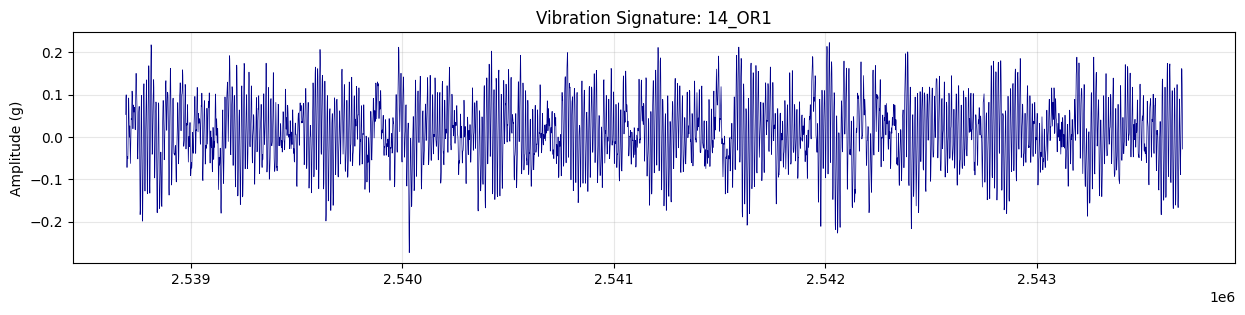

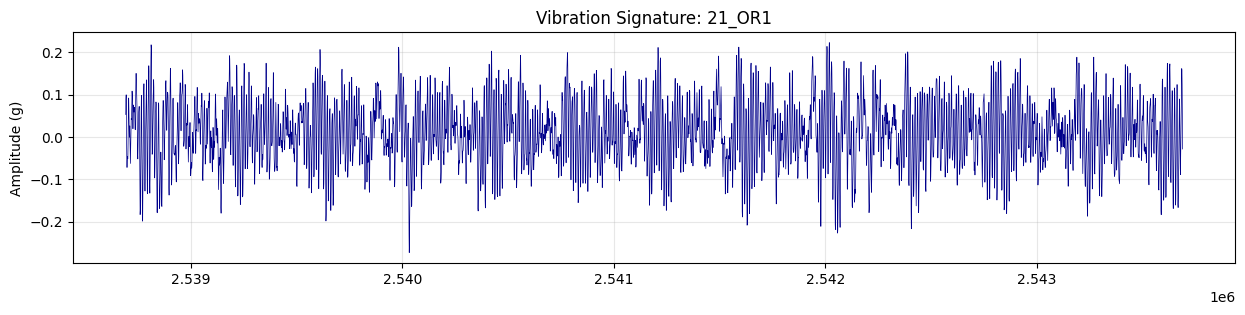

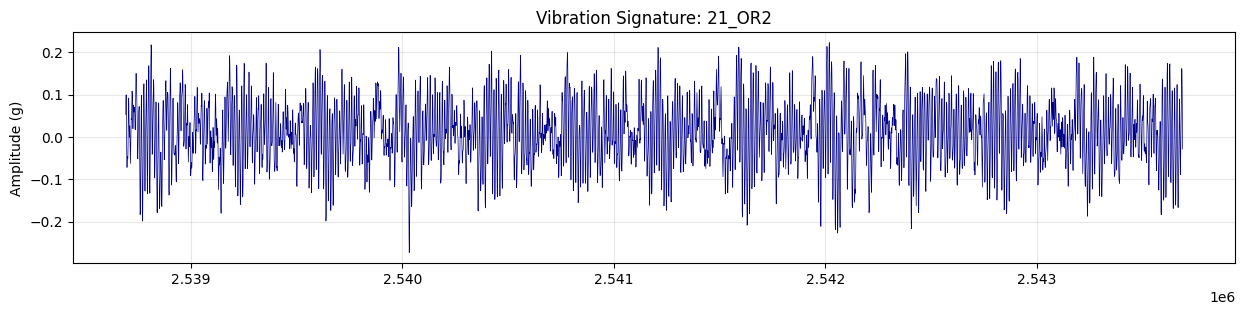

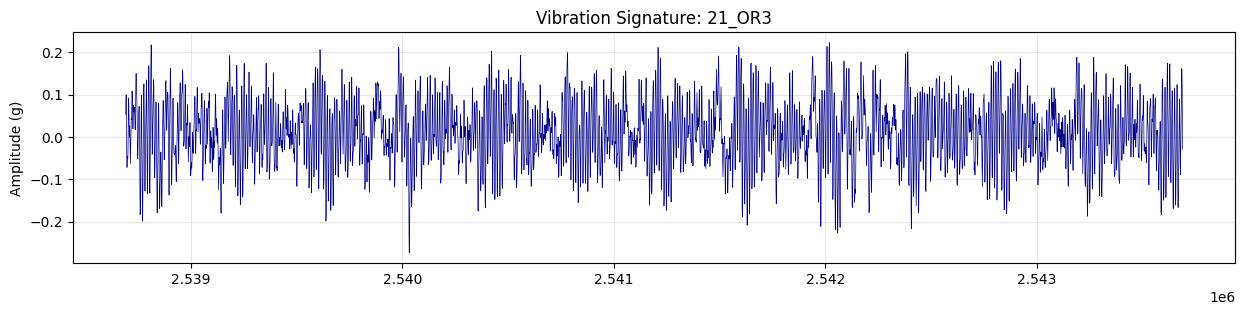

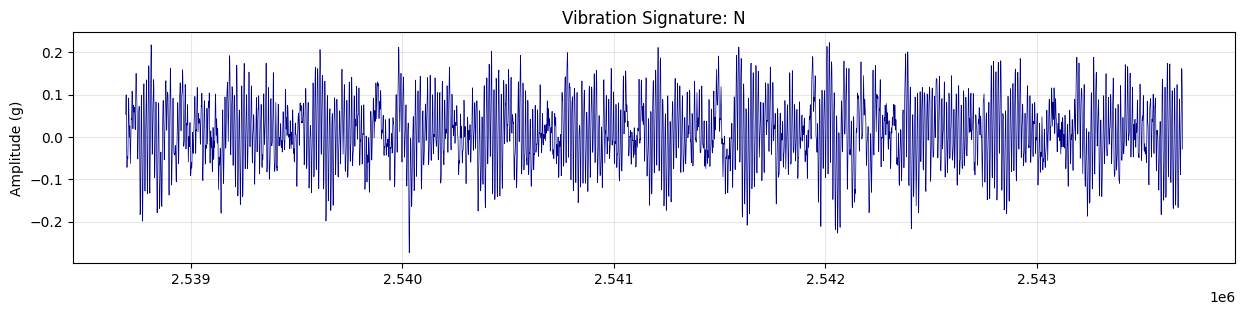

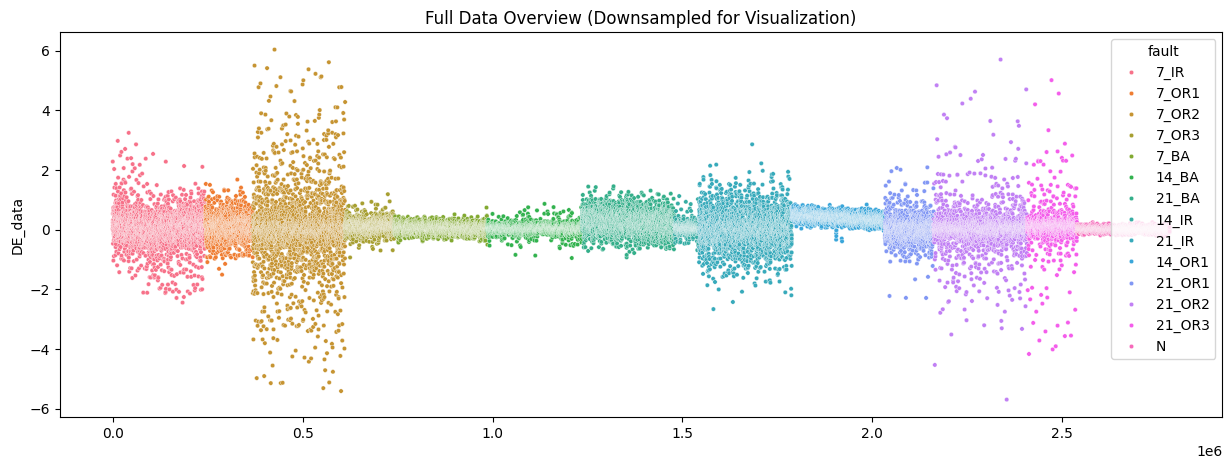

In [5]:
import scipy.io
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

folder_path = "0 load 48kHz"
all_chunks = [] # We use a list for faster processing

for root, dirs, files in os.walk(folder_path):
    for file_name in files:
        if file_name.endswith('.mat'):
            path = os.path.join(root, file_name)
            mat = scipy.io.loadmat(path)
            
            # DYNAMIC KEY SEARCH: Find the DE_time key regardless of its index
            de_key = [k for k in mat.keys() if 'DE_time' in k]
            if not de_key:
                print(f"Skipping {file_name}: No DE_time data found.")
                continue
            
            DE_data = mat[de_key[0]].flatten()
            
            # Create a temporary dataframe for this specific file
            # Using 'category' type for fault saves massive RAM
            fault_label = file_name.replace('.mat', '')
            df_temp = pd.DataFrame({
                'DE_data': DE_data.astype(np.float32), # float32 is better for Edge/CNN
                'fault': fault_label
            })
            
            all_chunks.append(df_temp)
            print(f"Processed: {fault_label} | Points: {len(DE_data)}")

# Efficiently merge everything at once
df = pd.concat(all_chunks, axis=0, ignore_index=True)

# 1. SAVE AS PARQUET (The format you asked for)
# You need 'pip install pyarrow'
df.to_parquet('CWRU_48khz_raw.parquet', engine='pyarrow', index=False)
print("\n✅ Saved to CWRU_48khz_raw.parquet (High Speed)")

# 2. VISUALIZATION: Plot by fault type
faults = df['fault'].unique()
for f in faults:
    plt.figure(figsize=(15, 3))
    # Plotting only the first 5000 points so the plot is readable
    
    plt.plot(signal_slice, linewidth=0.5, color='darkblue')
    plt.title(f"Vibration Signature: {f}")
    plt.ylabel("Amplitude (g)")
    plt.grid(True, alpha=0.3)
    plt.show()

# 3. GLOBAL SCATTER PLOT
plt.figure(figsize=(15, 5))
sns.scatterplot(data=df.iloc[::100, :], y='DE_data', x=np.arange(0, len(df), 100), hue='fault', s=10)
plt.title("Full Data Overview (Downsampled for Visualization)")
plt.show()